In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math as mm
import opstool as opst
import time as tt

In [2]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (109895368474)>


In [5]:
#==============================================================================
#Input Variables
'''
nDMaterial('PM4Sand', matTag, Dr, G0, hpo, rho, P_atm, h0, e_max, e_min, 
           nb, nd, Ado, z_max, c_z, c_e, phi_cv, nu, g_degr, c_dr, c_kaf, 
           Q, R, m_par, F_sed, p_sed)
'''
atm = -101.325
sig_v0 = 2.0* atm #initial vertical stress
CSR = 0.2 #cyclic stress ratio
Cycle_max = 5 #maximxum number of cycles
strain_in = 5.0e-6 #strain increment
K0 = 0.5
nu = K0/(1+K0) #poisson's ratio
devDisp = 0.03 #cutoff shear strain
perm = 1e-9 #permeability
#==============================================================================

#primary parameters
Dr = 0.5
G0 = 476.0
hpo = 0.53 #Contraction rate parameter
rho = 1.42 #mass density, KN/m3

#secondary parameters
P_atm = 101.325
# all initial stress dependant parameters have negative default values 
# and will be calculated during initialization
h0 = -1.0  #Variable that adjusts the ratio of plastic modulus to elastic modulus
e_max = 0.8
e_min = 0.5
e_ini = e_max - (e_max - e_min)*Dr #initial void ratio
nb = 0.5 #Bounding surface parameter, nb>=0
nd = 0.1 #Dilatancy surface parameter, nd>=0
Ado = -1.0
#Dilatancy parameter, will be computed at the time of initialization if input value is negative
z_max = -1.0 #Fabric-dilatancy tensor parameter
c_z = 250.0 #Fabric-dilatancy tensor parameter
c_e = -1.0 #Fabric-dilatancy tensor parameter
phi_cv = 26.0 #Critical state effective friction angle
g_degr = 2.0 #Variable that adjusts degradation of elastic modulus with accumulation of fabric
c_dr = -1.0 #Variable that controls the rotated dilatancy surface
c_kaf = -1.0 # Variable that controls the effect that sustained static shear stresses have on plastic modulus
Q = 10.0 #Critical state line parameter
R = 1.5 #Critical state line parameter
m_par = 0.01#Yield surface constant
F_sed = -1.0#Variable that controls the minimum value the reduction factor of the elastic moduli can get during reconsolidation
p_sed = -1.0#Mean effective stress up to which reconsolidation strains are enhanced

##%%
#Rayleigh Damping Parameters
'''
rayleigh(alphaM, betaK, betaKinit, betaKcomm)
'''
damp = 0.02
omega1 = 0.2
omega2 = 20.0
a1 = 2.0*damp/(omega1+omega2) #a1 is alphaM
a0 = a1*omega1*omega2 #a0 is betaK
##%%
#create model
#Remove the existing model, important!!! 
ops.wipe()

# set modelbuilder
ops.model('basic', '-ndm', 2, '-ndf', 3)

#model nodes
x1 = 0.0
y1 = 0.0

x2 = 1.0
y2 = 0.0

x3 = 1.0
y3 = 1.0

x4 = 0.0
y4 = 1.0

#create nodes

ops.node(1, x1, y1)
ops.node(2, x2, y2)
ops.node(3, x3, y3)
ops.node(4, x4, y4)

#boundary conditions
ops.fix(1, 1, 1, 1)
ops.fix(2, 1, 1, 1)
ops.fix(3, 0, 0, 1)
ops.fix(4, 0, 0, 1)
ops.equalDOF(3,4,1,2) #make node 3 and 4 equal displacement at degrees 1 & 2

#material
#==================================================================
#nDMaterial('PM4Sand', matTag, D_r, G_o, h_po, Den, P_atm, h_o, e_max, 
#e_min, n_b, n_d, A_do, z_max, c_z, c_e, phi_cv, nu, g_degr, c_dr, c_kaf, 
#Q_bolt, R_bolt, m_par, F_sed, p_sed)
#==================================================================
ops.nDMaterial(
            "PressureDependMultiYield02",
            5,
            2, # number of dimension
            1.8*UNIT.ton / UNIT.m3, #rho ton /m3
            9600.0, # ref shear modulus kpa
            27000.0, #ref bulk modulus kPa
            36, # friction angle
            0.1, # peak stress unit less
            101.0, #reference pressure kpa
            0.0, # press Dependent coefficient 
            26, #PT angle
            0.067, # Contrac 1 unit less
            0.23, # Contrac 3 unit less
            0.06, # dilatation 1 unit less
            0.27, # dilatation 3 unit less
            20, #no Yield Surf
            5.0, #Contrac 2 unit less
            3.0, #Contrac 3 unit less
            1.0, # liquefac1
            0.0, # liquefac2
            0.77, # e
            0.9, # cs1
            0.02, # cs2
            0.7, # cs3
            101.0, # pa kPa
        )

#element
ops.element('SSPquadUP',1, 1,2,3,4, 5, 1.0, 2.2e6, 1.0, perm, perm, e_ini, 1.0e-5)

#create recorders
ops.recorder('Node','-file', 'Cycdisp.txt','-time', '-node',1,2,3,4,'-dof', 1, 2, 'disp')
ops.recorder('Node','-file', 'CycPP.txt','-time', '-node',1,2,3,4,'-dof', 3, 'vel')
ops.recorder('Element','-file', 'Cycstress.txt','-time','-ele', 1, 'stress')
ops.recorder('Element','-file', 'Cycstrain.txt','-time','-ele', 1, 'strain')
##%%
#Analysis officially starts here
ops.constraints('Transformation')
ops.test('NormDispIncr', 1.0e-5, 35, 1)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.system('FullGeneral')
ops.integrator('Newmark', 5.0/6.0, 4.0/9.0)
ops.rayleigh(a1, a0, 0.0, 0.0) #modification
ops.analysis('Transient')

##%%apply consolidation pressure
pNode = sig_v0/2.0 #put confining pressure evenly on two nodes

# create a plain load pattern with time series 1
ops.timeSeries('Path', 1, '-values', 0, 1, 1, '-time', 0.0, 100.0, 1.0e10)
ops.pattern("Plain", 1, 1, '-factor',1.0)
ops.load(3, 0.0, pNode, 0.0) #apply vertical pressure at y direction
ops.load(4, 0.0, pNode, 0.0)
ops.updateMaterialStage('-material', 1, '-stage', 0)
ops.analyze(100,1.0)
vDisp = ops.nodeDisp(3,2)
b = ops.eleResponse(1, 'stress') #b = [sigmaxx, sigmayy, sigmaxy]
print('shear stress is',b[2])
ops.timeSeries('Path', 2, '-values', 1.0, 1.0, 1.0, '-time', 100.0, 80000.0, 1.0e10, '-factor', 1.0)
ops.pattern('Plain', 2, 2,'-factor',1.0)
ops.sp(3, 2, vDisp)
ops.sp(4, 2, vDisp)

#Close Drainage
for i in range(4):
    ops.remove('sp', i+1, 3)
    print('Node ID', i+1)


ops.analyze(25,1.0)
b = ops.eleResponse(1, 'stress') #b = [sigmaxx, sigmayy, sigmaxy]
print('shear stress is',b[2])
print('Drainage is closed')

ops.updateMaterialStage('-material', 1, '-stage', 1)
'''
Note:
The program will use the default value of a secondary parameter if 
a negative input is assigned to that parameter, e.g. Ado = -1. 
However, FirstCall is mandatory when switching from elastic to elastoplastic 
if negative inputs are assigned to stress-dependent secondary parameters, 
e.g. Ado and zmax. 
'''

#setParameter('-value', 0, '-ele', elementTag, 'FirstCall', matTag)
ops.setParameter('-val', 0, '-ele', 1, 'FirstCall', '1')

ops.analyze(25,1.0)
b = ops.eleResponse(1, 'stress') #b = [sigmaxx, sigmayy, sigmaxy]
print('shear stress is',b[2])
print('finished update fixties')
# update Poisson's ratio for analysis
#setParameter -value 0.3 -ele 1 poissonRatio 1
ops.setParameter('-val', 0.3, '-ele',1, 'poissonRatio', '1')

shear stress is -104.88088787780505
Node ID 1
Node ID 2
Node ID 3
Node ID 4
shear stress is -104.8808878778056
Drainage is closed
shear stress is -104.88088787780512
finished update fixties


SSPquadUP element - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington
CTestNormDispIncr::test() - iteration: 1 current Norm: 5.01694e-05 (max: 1e-05, Norm R: 4.44089e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.09942e-20 (max: 1e-05, Norm R: 4.44089e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 5.14985e-05 (max: 1e-05, Norm R: 0)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 5.05331e-05 (max: 1e-05, Norm R: 9.93014e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 5.06001e-20 (max: 1e-05, Norm R: 4.44089e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 5.11493e-05 (max: 1e-05, Norm R: 0)
CTestNormDispIncr::test() - iteration: 2 current Norm: 0 (max: 1e-05, Norm R: 0)

CTestNormDispIncr::test() - iteration: 1 current Norm: 5.07845e-05 (max: 1e-05, Norm R: 1.77636e-15)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.39767

In [6]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [7]:
# Initialize ODB for response tracking
ODB = opst.post.CreateODB(
    odb_tag=1,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)

controlDisp = 1.1 * devDisp
numCycle = 0.25
print('Current Number of Cycle:', numCycle)

start = tt.time()
numCycle = 0.0

while numCycle <= Cycle_max:
    hDisp = ops.nodeDisp(3, 1)
    cur_time = ops.getTime()

    # 1/4 cycle: zero to +max stress
    steps = controlDisp / strain_in
    time_change = cur_time + steps
    ops.timeSeries("Path", 3, "-values", hDisp, controlDisp, controlDisp,
                   "-time", cur_time, time_change, 1.0e10, "-factor", 1.0)
    ops.pattern("Plain", 3, 3, "-fact", 1.0)
    ops.sp(3, 1, 1.0)

    b = ops.eleResponse(1, 'stress')
    print('shear stress is', b[2])

    while b[2] <= CSR * sig_v0 * -1.0:
        ops.analyze(1, 1.0)
        b = ops.eleResponse(1, 'stress')
        ODB.fetch_response_step()
        hDisp = ops.nodeDisp(3, 1)
        if hDisp >= devDisp:
            print('loading break')
            break

    numCycle += 0.25
    hDisp = ops.nodeDisp(3, 1)
    cur_time = ops.getTime()

    # Clean up
    ops.remove('loadPattern', 3)
    ops.remove('timeSeries', 3)
    ops.remove('sp', 3, 1)

    # 1/2 cycle: +max to -max
    steps = (controlDisp + hDisp) / strain_in
    time_change = cur_time + steps
    ops.timeSeries("Path", 3, "-values", hDisp, -controlDisp, -controlDisp,
                   "-time", cur_time, time_change, 1.0e10, "-factor", 1.0)
    ops.pattern("Plain", 3, 3)
    ops.sp(3, 1, 1.0)

    while b[2] > CSR * sig_v0:
        ops.analyze(1, 1.0)
        b = ops.eleResponse(1, 'stress')
        ODB.fetch_response_step()
        print('shear stress is', b[2])
        hDisp = ops.nodeDisp(3, 1)
        if hDisp <= -devDisp:
            print('unloading break')
            break

    numCycle += 0.5
    hDisp = ops.nodeDisp(3, 1)
    cur_time = ops.getTime()

    # Clean up
    ops.remove('loadPattern', 3)
    ops.remove('timeSeries', 3)
    ops.remove('sp', 3, 1)

    # Final 1/4 cycle: back to zero stress
    steps = (controlDisp + hDisp) / strain_in
    time_change = cur_time + steps
    ops.timeSeries("Path", 3, "-values", hDisp, controlDisp, controlDisp,
                   "-time", cur_time, time_change, 1.0e10, "-factor", 1.0)
    ops.pattern("Plain", 3, 3, "-fact", 1.0)
    ops.sp(3, 1, 1.0)

    while b[2] <= 0.0:
        ops.analyze(1, 1.0)
        b = ops.eleResponse(1, 'stress')
        ODB.fetch_response_step()
        print('shear stress is', b[2])
        hDisp = ops.nodeDisp(3, 1)
        if hDisp >= devDisp:
            print('reloading break')
            break

    numCycle += 0.25
    print('Current Number of Cycle:', numCycle)
    ops.remove('loadPattern', 3)
    ops.remove('timeSeries', 3)

ODB.save_response(zlib=True)
print("ODB response saved")


Current Number of Cycle: 0.25
shear stress is -104.88088787780512


CTestNormDispIncr::test() - iteration: 1 current Norm: 40481.6 (max: 1e-05, Norm R: 6.88831e-17)
CTestNormDispIncr::test() - iteration: 2 current Norm: 9.16967e-10 (max: 1e-05, Norm R: 6.43821e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 41285.9 (max: 1e-05, Norm R: 1.5474e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.54262e-10 (max: 1e-05, Norm R: 2.29702e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 42090.1 (max: 1e-05, Norm R: 8.97111e-18)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.78534e-10 (max: 1e-05, Norm R: 2.30176e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 42894.4 (max: 1e-05, Norm R: 1.01981e-17)
CTestNormDispIncr::test() - iteration: 2 current Norm: 2.02948e-10 (max: 1e-05, Norm R: 2.2934e-19)

CTestNormDispIncr::test() - iteration: 1 current Norm: 43698.7 (max: 1e-05, Norm R: 2.11838e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 1.00247e-09 (max: 1e-05, Norm R: 2.30176e-19)

CTestNo

loading break
shear stress is -104.88334025875747
reloading break
Current Number of Cycle: 1.0
shear stress is -104.88334025875747
loading break
shear stress is -104.8833396656264
reloading break
Current Number of Cycle: 2.0
shear stress is -104.8833396656264
loading break
shear stress is -104.88333907264753
reloading break
Current Number of Cycle: 3.0
shear stress is -104.88333907264753
loading break
shear stress is -104.88333847982085
reloading break
Current Number of Cycle: 4.0
shear stress is -104.88333847982085
loading break
shear stress is -104.8833378871463
reloading break
Current Number of Cycle: 5.0
shear stress is -104.8833378871463
loading break
shear stress is -104.88333729462381
reloading break
Current Number of Cycle: 6.0


OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

ODB response saved


In [8]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = True)

Analysis is done!
Computation time is 17.126652479171753


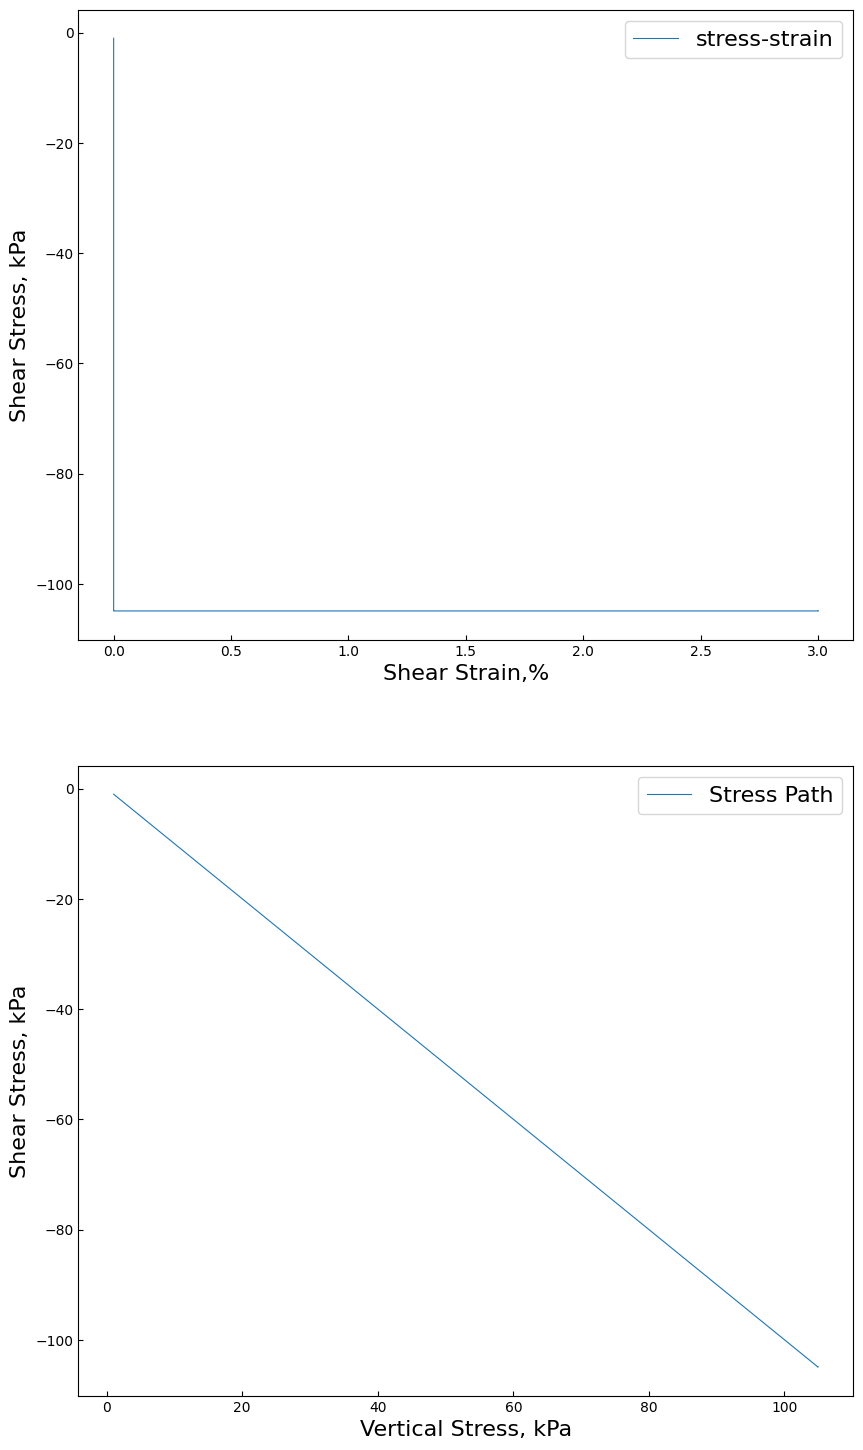

In [9]:
ops.wipe()
print('Analysis is done!')
end = tt.time()
run_time = end-start
print('Computation time is' , run_time)
##%%PostProcessing
import pandas as pd
df_stress = pd.read_csv('Cycstress.txt', sep=" ", header=None)
df_strain = pd.read_csv('Cycstrain.txt', sep=" ", header=None)
#df_PP = pd.read_csv('CycPP.txt', sep=" ", header=None)

Stress_V = df_stress.iloc[:, 1].to_numpy()*(-1.0) #compression is positive 
Shear_Stress = df_stress.iloc[:, 3].to_numpy()
Shear_Strain = df_strain.iloc[:, 3].to_numpy()*100.0

fig = plt.figure(figsize=(10,18))
ax0 = fig.add_subplot(211)
ax0.plot(Shear_Strain, Shear_Stress, label='stress-strain', linewidth=0.8)
ax0.set_xlabel("Shear Strain,%", fontsize=16)
ax0.set_ylabel("Shear Stress, kPa", fontsize=16)
ax0.legend(fontsize=16)

ax1 = fig.add_subplot(212)
ax1.plot(Stress_V, Shear_Stress, label='Stress Path', linewidth=0.8)
ax1.set_xlabel("Vertical Stress, kPa", fontsize=16)
ax1.set_ylabel("Shear Stress, kPa", fontsize=16)
ax1.legend(fontsize=16)
plt.show()
plt.close()

In [10]:
ele_resp = opst.post.get_element_responses(odb_tag=1, ele_type="Plane")

OPSTOOL ::  Loading Plane response data from .opstool.output/RespStepData-1.nc ...

In [11]:
print("Data Variables in Element Responses:", ele_resp.data_vars)

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 120kB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 72kB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 481kB 0.0 ......
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 289kB 0.0 ......
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 481kB 0.0 ......
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 289kB 0.0 ......
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 96kB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 96kB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 385kB 0.0 ... 0.0
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 385kB 0.0 ... 0.0


In [12]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1)
sigma33 = 0
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=1)
#eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=1)

In [13]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 6012, GaussPoints: 1)> Size: 24kB
array([[-82.74202],
       [ 82.76378],
       [ 82.76382],
       ...,
       [249.30692],
       [249.31139],
       [249.31204]], shape=(6012, 1), dtype=float32)
Coordinates:
  * time         (time) float32 24kB 0.0 151.0 152.0 ... 6.16e+03 6.161e+03
    eleTags      int64 8B 1
  * GaussPoints  (GaussPoints) int64 8B 1
    stressDOFs   <U7 28B 'sigma12'


In [14]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=1)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=1)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=1)

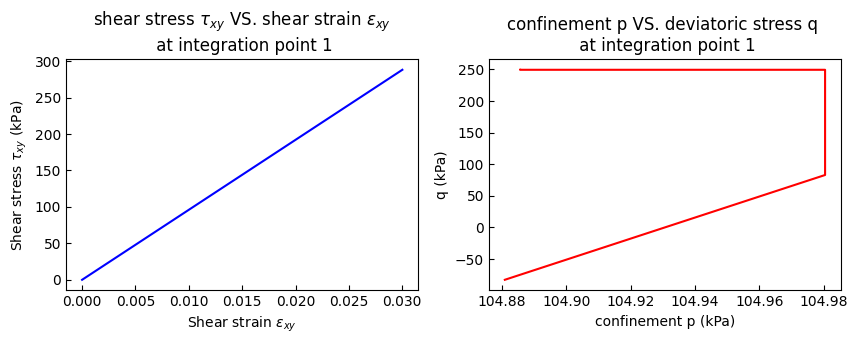

In [15]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
sigma11_ele1_1 = sigma11.sel(GaussPoints=1)
#po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(-sigma11_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

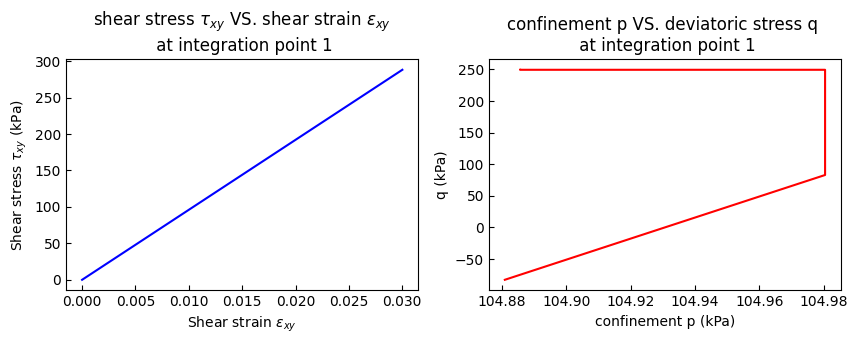

In [16]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
sigma11_ele1_1 = sigma11.sel(GaussPoints=1)
#po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(-sigma11_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

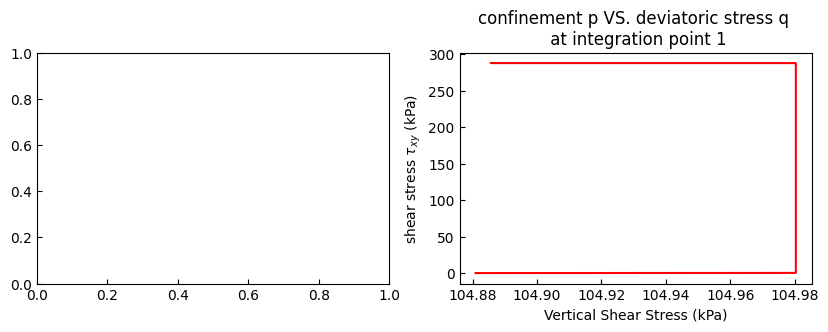

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[1].plot(-sigma11, sigma12, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("Vertical Shear Stress (kPa)")
axs[1].set_ylabel("shear stress $\\tau_{xy}$ (kPa)")
plt.show()

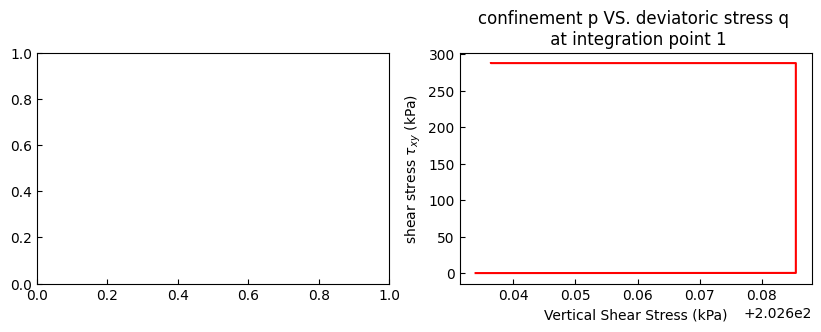

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[1].plot(-sigma22, sigma12, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("Vertical Shear Stress (kPa)")
axs[1].set_ylabel("shear stress $\\tau_{xy}$ (kPa)")
plt.show()

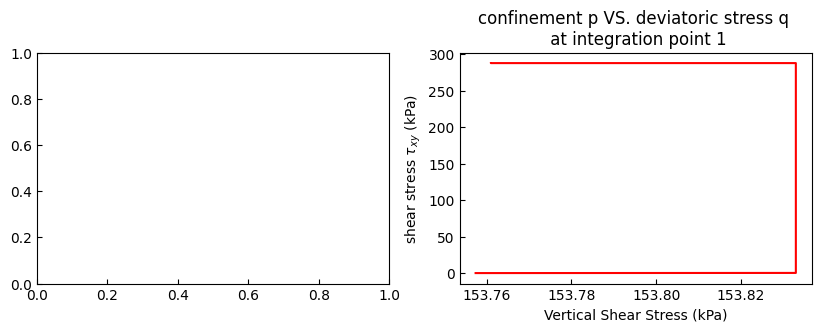

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[1].plot(-((sigma22+sigma11)/2), sigma12, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("Vertical Shear Stress (kPa)")
axs[1].set_ylabel("shear stress $\\tau_{xy}$ (kPa)")
plt.show()

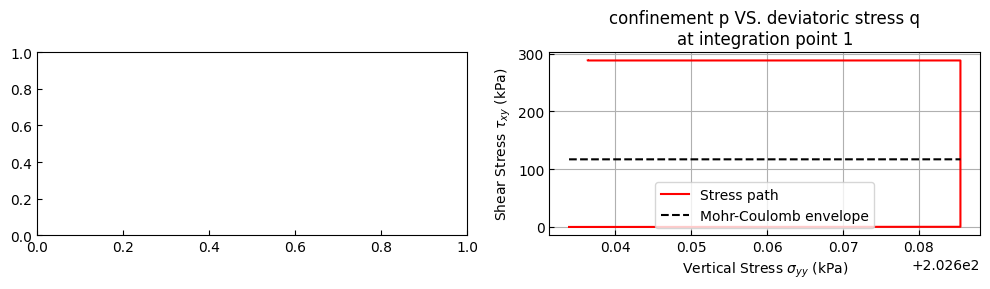

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- INPUTS ---
phi_deg = 30         # Friction angle in degrees
cohesion = 0        # Cohesion in kPa

# --- DATA (you already have these) ---
# sigma22: vertical (normal) stress
# sigma12: shear stress
# Make sure they are NumPy arrays
sigma22 = np.array(sigma22)
sigma12 = np.array(sigma12)

# --- MOHR-COULOMB FAILURE ENVELOPE ---
phi_rad = np.radians(phi_deg)
sigma_range = np.linspace(min(-sigma22), max(-sigma22), 100)
tau_failure = cohesion + sigma_range * np.tan(phi_rad)

# --- PLOTTING ---
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[1].plot(-sigma22, sigma12, "r", label="Stress path")
axs[1].plot(sigma_range, tau_failure, "k--", label="Mohr-Coulomb envelope")
axs[1].set_title("confinement p VS. deviatoric stress q\nat integration point 1")
axs[1].set_xlabel("Vertical Stress $\\sigma_{yy}$ (kPa)")
axs[1].set_ylabel("Shear Stress $\\tau_{xy}$ (kPa)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


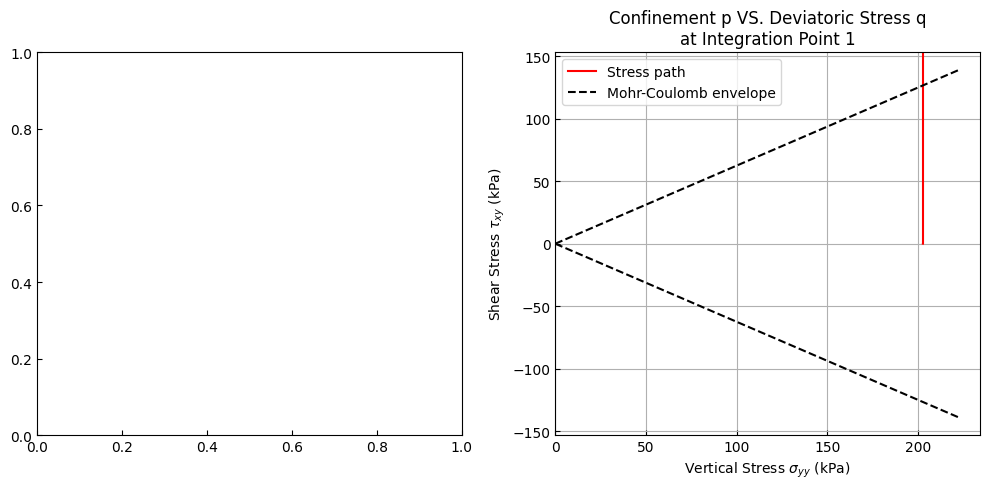

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs
phi_deg = 32          # Friction angle in degrees
cohesion = 0        # Cohesion in kPa
phi_rad = np.radians(phi_deg)

# Stress data (replace with actual values)
sigma22 = np.array(sigma22)  # Vertical normal stress
sigma12 = np.array(sigma12)  # Shear stress

# Envelope range
sigma_range = np.linspace(0, max(-sigma22) * 1.1, 200)
tau_pos = cohesion + sigma_range * np.tan(phi_rad)
tau_neg = -cohesion + sigma_range * np.tan(phi_rad)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[1].plot(-sigma22, sigma12, "r", label="Stress path")

# Mohr-Coulomb envelopes
axs[1].plot(sigma_range, tau_pos, "k--", label="Mohr-Coulomb envelope")
axs[1].plot(sigma_range, -tau_pos, "k--")  # mirrored envelope

# Labels and layout
axs[1].set_title("Confinement p VS. Deviatoric Stress q\nat Integration Point 1")
axs[1].set_xlabel("Vertical Stress $\\sigma_{yy}$ (kPa)")
axs[1].set_ylabel("Shear Stress $\\tau_{xy}$ (kPa)")
axs[1].legend()
axs[1].grid(True)
axs[1].set_xlim(left=0)
axs[1].set_ylim(
    bottom=min(-tau_pos)*1.1,
    top=max(tau_pos)*1.1
)

plt.tight_layout()
plt.show()
